# 23CSE463 – Quantum Computing
## Worksheet 6: Implementation of Shor\'s Algorithm for Integer Factorization Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 6

**Aim:** To implement the quantum period-finding part of Shor\'s algorithm in Qiskit for N = 15, and to use the measured period with classical post-processing to obtain the prime factors.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


from math import gcd
from fractions import Fraction

N = 15

def period(a, N):
    r, v = 1, a % N
    while v != 1:
        v = (v * a) % N; r += 1
    return r

def qft(n):
    qc = QuantumCircuit(n, name=f"QFT{n}")
    for j in reversed(range(n)):
        qc.h(j)
        for k in reversed(range(j)):
            qc.cp(np.pi / 2 ** (j - k), k, j)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

def iqft(n):                       # reused from Experiment 5
    g = qft(n).inverse(); g.name = f"IQFT{n}"
    return g

def mult_mod15(a):
    """4-qubit circuit |y> -> |a*y mod 15> (shortcut valid for N = 15)"""
    U = QuantumCircuit(4, name=f"x{a} mod 15")
    if a == 7:
        U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        U.x(range(4))
    elif a == 11:
        U.swap(1, 3); U.swap(0, 2)
        U.x(range(4))
    else:
        raise ValueError("only a = 7 and a = 11 are implemented")
    return U

def shor_circuit(a, t=8):
    qc = QuantumCircuit(t + 4, t)
    qc.h(range(t))                 # counting register
    qc.x(t)                        # work register = |1>
    qc.barrier()
    U = mult_mod15(a)
    for j in range(t):
        cU = U.power(2 ** j).to_gate(label=f"{a}^{2**j}").control()
        qc.append(cU, [j] + list(range(t, t + 4)))
    qc.barrier()
    qc.append(iqft(t).to_gate(label="IQFT"), range(t))
    qc.measure(range(t), range(t))
    return qc


Qiskit version: 2.5.2


### Program 1
Classically compute $7^{x}\text{ mod }15$ for $x$ = 0 to 12 and plot the values. Read the period from the plot.

 x :   0   1   2   3   4   5   6   7   8   9  10  11  12
7^x:   1   7   4  13   1   7   4  13   1   7   4  13   1


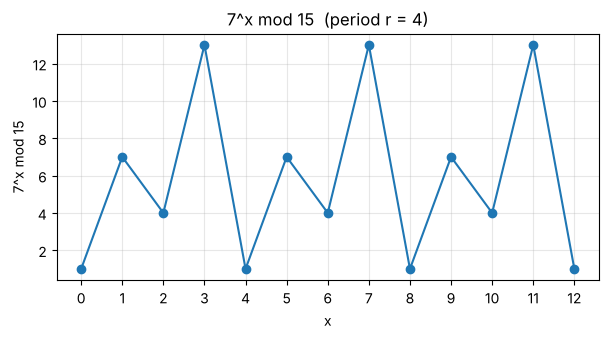

Period read from the plot / table: r = 4


In [2]:
# Program 1: 7^x mod 15 for x = 0..12
xs = np.arange(13)
vals = [pow(7, int(x), N) for x in xs]
print(" x :", " ".join(f"{x:>3}" for x in xs))
print("7^x:", " ".join(f"{v:>3}" for v in vals))
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(xs, vals, "o-")
ax.set_xlabel("x"); ax.set_ylabel("7^x mod 15"); ax.set_title("7^x mod 15  (period r = 4)")
ax.set_xticks(xs); ax.grid(alpha=.3)
show(fig)
print("Period read from the plot / table: r =", period(7, N))

**Inference:** The values repeat 1, 7, 4, 13, 1, 7, 4, 13, … so the sequence is periodic with period r = 4 (7⁴ = 2401 ≡ 1 mod 15).

### Program 2
For every $a$ in 2, 4, 7, 8, 11, 13 and 14, compute the period $r$ classically and the two values $\gcd\left( a^{r/2} \pm 1,15 \right)$. Tabulate the results, identify the value of $a$ that fails to give the factors and explain why.

In [3]:
# Program 2: period and factors for every a
print("  a  gcd(a,15)  r   a^(r/2) mod 15   gcd(a^(r/2)-1,15)  gcd(a^(r/2)+1,15)  result")
for a in [2, 4, 7, 8, 11, 13, 14]:
    r = period(a, N)
    if r % 2:
        print(f" {a:>2}     {gcd(a,N)}     {r}   odd period -> fail"); continue
    h = pow(a, r // 2, N)
    p, q = gcd(h - 1, N), gcd(h + 1, N)
    ok = {p, q} == {3, 5}
    note = "factors 3 x 5" if ok else f"FAILS (a^(r/2) = {h} = -1 mod 15)"
    print(f" {a:>2}     {gcd(a,N)}      {r}        {h:>2}               {p:>2}                {q:>2}         {note}")

  a  gcd(a,15)  r   a^(r/2) mod 15   gcd(a^(r/2)-1,15)  gcd(a^(r/2)+1,15)  result
  2     1      4         4                3                 5         factors 3 x 5
  4     1      2         4                3                 5         factors 3 x 5
  7     1      4         4                3                 5         factors 3 x 5
  8     1      4         4                3                 5         factors 3 x 5
 11     1      2        11                5                 3         factors 3 x 5
 13     1      4         4                3                 5         factors 3 x 5
 14     1      2        14                1                15         FAILS (a^(r/2) = 14 = -1 mod 15)


**Inference:** Every a except 14 gives the factors 3 and 5 (periods 4 for a = 2, 7, 8, 13 and 2 for a = 4, 11). For a = 14, r = 2 and a^(r/2) = 14 ≡ −1 (mod 15), so gcd(13,15) = 1 and gcd(15,15) = 15 are trivial factors; such an a must be rejected and another chosen.

### Program 3
Build the four-qubit circuit that multiplies by 7 modulo 15. Verify with Statevector that repeated application takes $|1\rangle$ to $|7\rangle$, $|4\rangle$, $|13\rangle$ and back to $|1\rangle$.

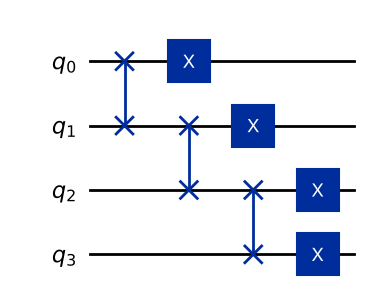

Repeated application to |1>: |1> -> |7> -> |4> -> |13> -> |1>
Check on all inputs 1..14 (y -> 7y mod 15): True


In [4]:
# Program 3: multiply-by-7 mod 15 circuit
U7 = mult_mod15(7)
show(U7.draw("mpl"))
sv = Statevector.from_label("0001")        # |1>
seq = [1]
for _ in range(4):
    sv = sv.evolve(U7)
    seq.append(int(np.argmax(np.abs(sv.data))))
print("Repeated application to |1>:", " -> ".join(f"|{v}>" for v in seq))
print("Check on all inputs 1..14 (y -> 7y mod 15):",
      all(int(np.argmax(np.abs(Statevector.from_int(y, 16).evolve(U7).data))) == (7 * y) % 15 for y in range(1, 15)))

**Inference:** Applying the circuit repeatedly gives |1> → |7> → |4> → |13> → |1>, i.e. multiplication by 7 mod 15 with period 4; it is correct for every y = 1…14. The circuit is just a permutation of bits plus X gates, a shortcut that works only for N = 15.

### Program 4
Convert the multiplication circuit into a controlled gate, and build the controlled versions of its powers $2^{j}$ for $j$ = 0 to 7.

 j   power 2^j   U^(2^j)|1>   7^(2^j) mod 15
 0        1        | 7>          7
 1        2        | 4>          4
 2        4        | 1>          1
 3        8        | 1>          1
 4       16        | 1>          1
 5       32        | 1>          1
 6       64        | 1>          1


 7      128        | 1>          1

Controlled gate for j = 0: cx7 mod 15**1  qubits: 5


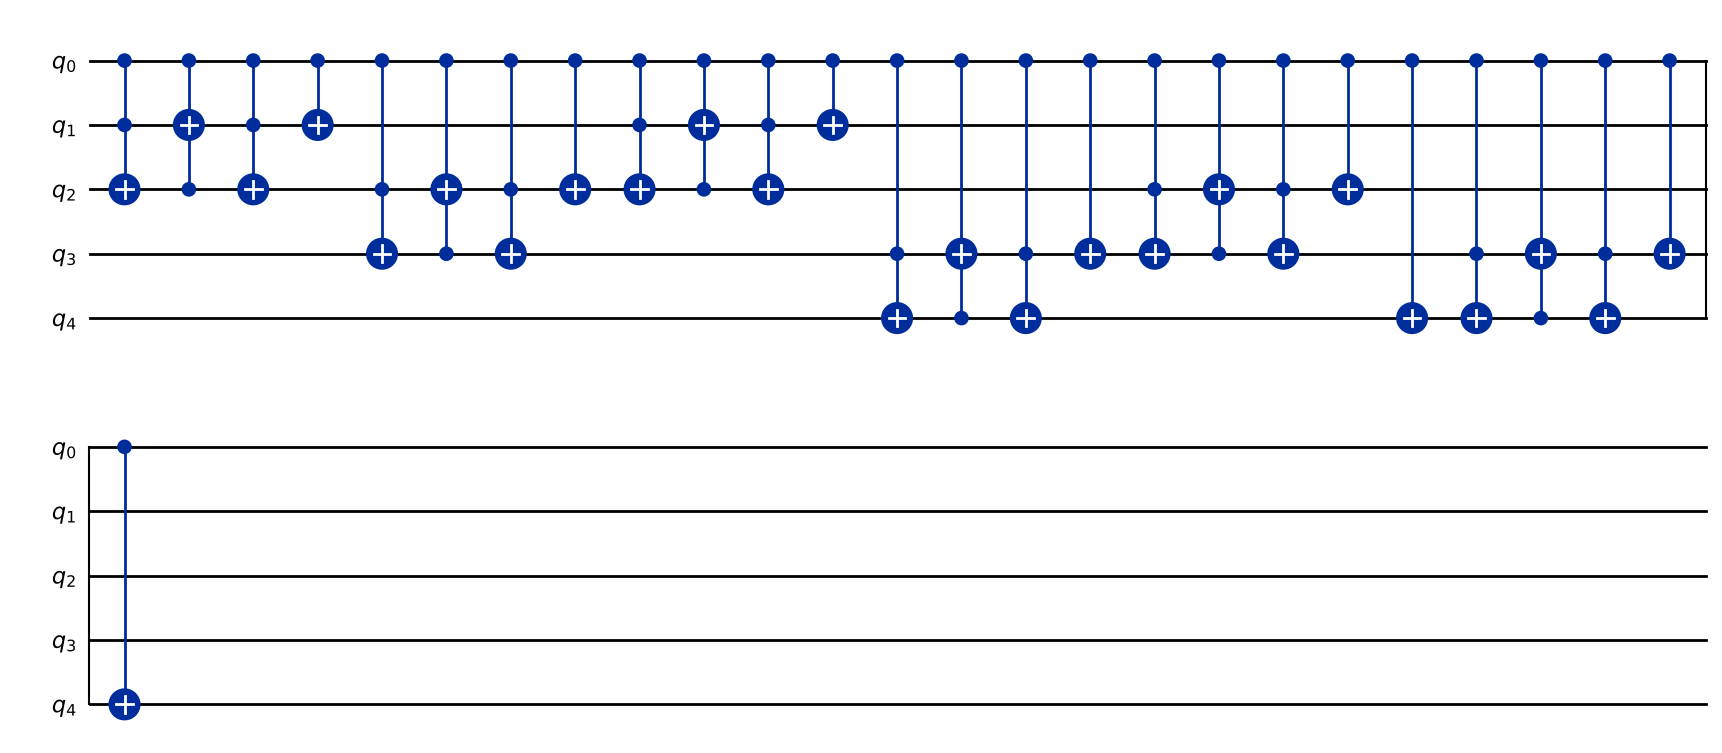

In [5]:
# Program 4: controlled powers U^(2^j), j = 0..7
print(" j   power 2^j   U^(2^j)|1>   7^(2^j) mod 15")
cgates = []
for j in range(8):
    P = U7.power(2 ** j)
    cgates.append(P.to_gate(label=f"7^{2**j}").control())
    out = int(np.argmax(np.abs(Statevector.from_int(1, 16).evolve(P).data)))
    print(f" {j}     {2**j:>4}        |{out:>2}>          {pow(7, 2**j, 15)}")
print("\nControlled gate for j = 0:", cgates[0].name, " qubits:", cgates[0].num_qubits)
demo = QuantumCircuit(5); demo.append(cgates[1], range(5))
show(demo.decompose().draw("mpl"))

**Inference:** Each controlled gate acts on 1 control + 4 work qubits. U^(2^j)|1> gives 7, 4, 1, 1, … because 7^(2^j) mod 15 = 7, 4, 1 for j = 0, 1, 2 and 1 for all j ≥ 2 (since r = 4 divides 2^j), so only the first two controlled powers actually change the work register.

### Program 5
Build the inverse QFT on eight qubits (reuse the function from Experiment 5) and verify it on one basis state.

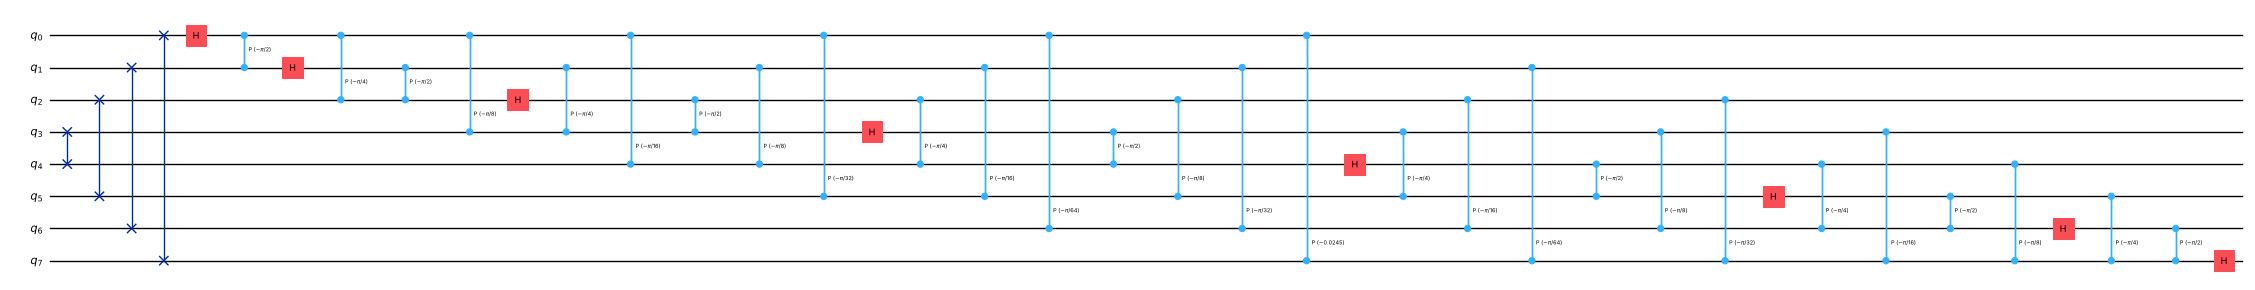

IQFT(QFT|64>) = |64>, probability 1.000000
IQFT8 . QFT8 = identity: True


In [6]:
# Program 5: 8-qubit inverse QFT, verified on one basis state
t = 8
c0 = 64
show(iqft(t).draw("mpl", fold=-1, scale=0.5))
sv =Statevector.from_int(c0, 2 ** t).evolve(qft(t)).evolve(iqft(t))
print(f"IQFT(QFT|{c0}>) = |{int(np.argmax(np.abs(sv.data)))}>, probability {np.max(np.abs(sv.data))**2:.6f}")
print("IQFT8 . QFT8 = identity:", Operator(qft(t).compose(iqft(t))).equiv(Operator(QuantumCircuit(t))))

**Inference:** The 8-qubit inverse QFT exactly undoes the QFT: QFT|64> followed by IQFT returns |64> with probability 1, and IQFT·QFT is the identity operator.

### Program 6
Assemble the complete period-finding circuit for a = 7 with eight counting qubits and four work qubits. Draw the circuit and report the number of qubits and the circuit depth.

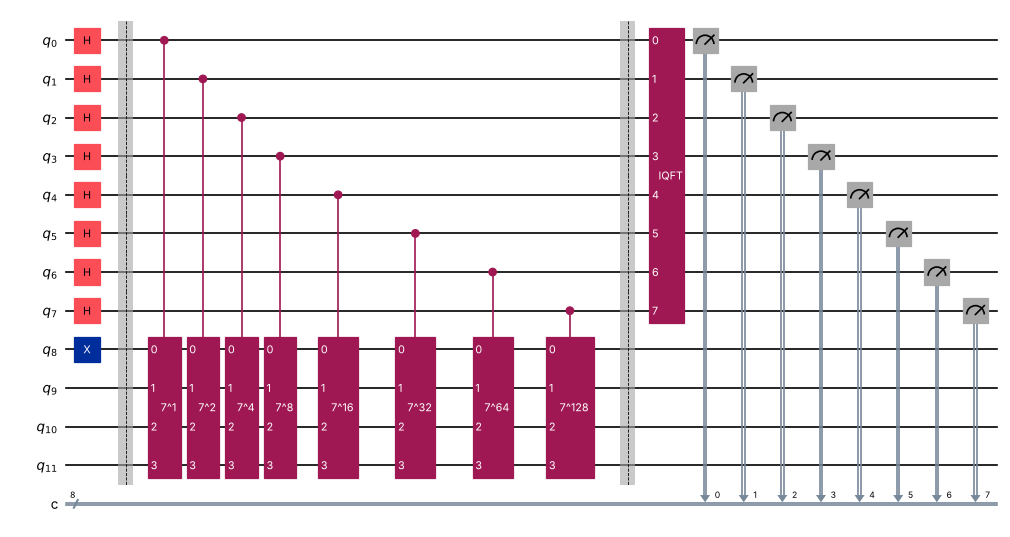

Qubits: 12 (8 counting + 4 work)   classical bits: 8
Depth (high-level gates): 11
Depth after transpiling for AerSimulator: 3297
Gate counts after transpiling: {'ccx': 2295, 'cx': 1020, 'cp': 28, 'h': 16, 'measure': 8, 'barrier': 2, 'x': 1}


In [7]:
# Program 6: complete period-finding circuit for a = 7
qc7 = shor_circuit(7)
show(qc7.draw("mpl", fold=-1, scale=0.6))
tq = transpile(qc7, sim)
print("Qubits:", qc7.num_qubits, "(8 counting + 4 work)   classical bits:", qc7.num_clbits)
print("Depth (high-level gates):", qc7.depth())
print("Depth after transpiling for AerSimulator:", tq.depth())
print("Gate counts after transpiling:", dict(tq.count_ops()))

**Inference:** The circuit has 12 qubits (8 counting, 4 work): Hadamards on the counting register, X to prepare |1>, eight controlled-U^(2^j) gates and the inverse QFT. Its high-level depth is small but the transpiled depth is much larger, because each controlled modular multiplication expands into many elementary gates.

### Program 7
Run the circuit with 1024 shots and plot the histogram. Tabulate each outcome as a bit string, as a decimal number c and as the phase c/256.

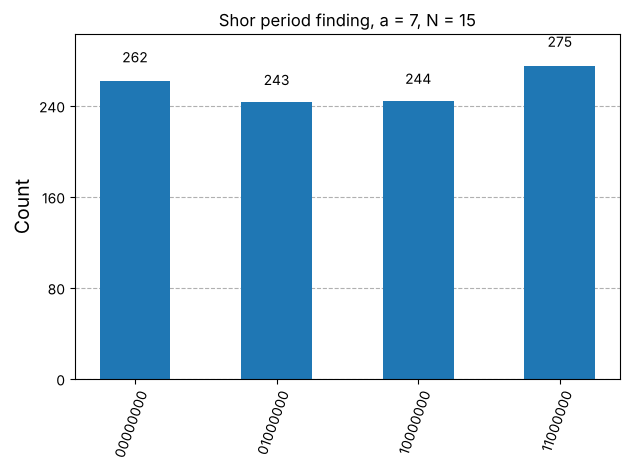

 bitstring   c    phase c/256
  00000000    0    0.0000    (262 counts)
  01000000   64    0.2500    (243 counts)
  10000000  128    0.5000    (244 counts)
  11000000  192    0.7500    (275 counts)


In [8]:
# Program 7: run with 1024 shots
counts7 = run(qc7, 1024)
show(plot_histogram(counts7, title="Shor period finding, a = 7, N = 15"))
print(" bitstring   c    phase c/256")
for b in sorted(counts7, key=lambda s: int(s, 2)):
    c = int(b, 2)
    print(f"  {b}  {c:>3}    {c/256:.4f}    ({counts7[b]} counts)")

**Inference:** Only four outcomes appear, each ≈25%: c = 0, 64, 128, 192, i.e. phases 0, 1/4, 1/2, 3/4 = s/4. With r = 4 dividing 2⁸, the inverse QFT gives exact peaks at multiples of 256/4 = 64.

### Program 8
Convert each phase to a fraction with Fraction(c, 256).limit_denominator(15) and list the candidate periods. Confirm the period and compute the prime factors of 15.

In [9]:
# Program 8: continued fractions -> period -> factors
a = 7
print(" c    phase    fraction   candidate r   7^r mod 15 == 1 ?")
cands = set()
for b in sorted(counts7, key=lambda s: int(s, 2)):
    c = int(b, 2)
    f = Fraction(c, 256).limit_denominator(N)
    r = f.denominator
    good = pow(a, r, N) == 1
    print(f" {c:>3}  {c/256:.4f}   {str(f):>6}       {r}            {good}")
    if good and r > 1:
        cands.add(r)
r = min(cands)
print("\nConfirmed period r =", r)
h = pow(a, r // 2, N)
print(f"a^(r/2) mod N = {h};  gcd({h}-1, 15) = {gcd(h-1, N)},  gcd({h}+1, 15) = {gcd(h+1, N)}")
print(f"15 = {gcd(h-1, N)} x {gcd(h+1, N)}")

 c    phase    fraction   candidate r   7^r mod 15 == 1 ?
   0  0.0000        0       1            False
  64  0.2500      1/4       4            True
 128  0.5000      1/2       2            False
 192  0.7500      3/4       4            True

Confirmed period r = 4
a^(r/2) mod N = 4;  gcd(4-1, 15) = 3,  gcd(4+1, 15) = 5
15 = 3 x 5


**Inference:** c = 64 and 192 give 1/4 and 3/4 → r = 4 (and 7⁴ mod 15 = 1); c = 128 gives 1/2 → r = 2, which fails the check (7² mod 15 = 4), and c = 0 gives no information. With r = 4: 7² mod 15 = 4, gcd(3,15) = 3 and gcd(5,15) = 5, so 15 = 3 × 5.

### Program 9
Repeat the experiment for a = 11, for which the multiplication is swap(1, 3), swap(0, 2) followed by an X gate on each of the four qubits. Explain why the histogram now has only two peaks, and obtain the factors.

Multiply-by-11 check: |1> -> |11> -> |1>


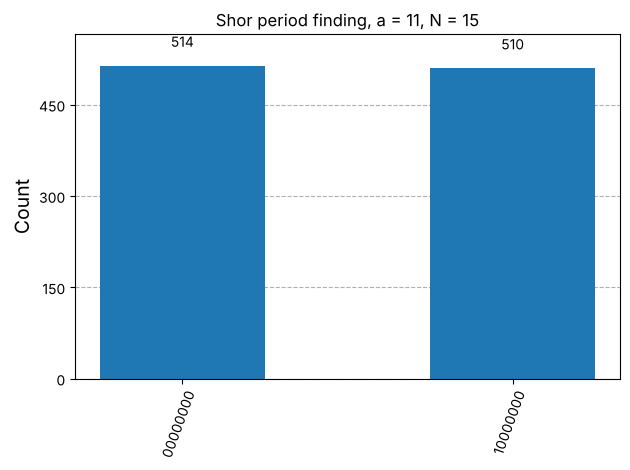

Outcomes: {128: 510, 0: 514}
Candidate periods: {1, 2}  -> r = 2   check 11^r mod 15 = 1
gcd(11-1, 15) = 5,  gcd(11+1, 15) = 3  ->  15 = 5 x 3


In [10]:
# Program 9: repeat for a = 11
U11 = mult_mod15(11)
sv = Statevector.from_int(1, 16); seq = [1]
for _ in range(2):
    sv = sv.evolve(U11); seq.append(int(np.argmax(np.abs(sv.data))))
print("Multiply-by-11 check:", " -> ".join(f"|{v}>" for v in seq))
qc11 = shor_circuit(11)
counts11 = run(qc11, 1024)
show(plot_histogram(counts11, title="Shor period finding, a = 11, N = 15"))
print("Outcomes:", {int(k, 2): v for k, v in counts11.items()})
rs = {Fraction(int(k, 2), 256).limit_denominator(N).denominator for k in counts11}
r = max(rs)
print("Candidate periods:", rs, " -> r =", r, "  check 11^r mod 15 =", pow(11, r, N))
h = pow(11, r // 2, N)
print(f"gcd({h}-1, 15) = {gcd(h-1, N)},  gcd({h}+1, 15) = {gcd(h+1, N)}  ->  15 = {gcd(h-1, N)} x {gcd(h+1, N)}")

**Inference:** 11·1 = 11 and 11·11 = 121 ≡ 1 (mod 15), so r = 2 and the histogram has only two peaks, c = 0 and c = 128 (phases 0 and 1/2), each ≈50%: with period 2 there are only two values of s/r. Then 11^(r/2) = 11, gcd(10,15) = 5 and gcd(12,15) = 3, again giving 15 = 3 × 5.

## Viva Q&A

**1. What problem does Shor\'s algorithm solve, and why does it matter for RSA?**  
It finds the prime factors of an integer N in polynomial time on a quantum computer. RSA's security rests on factoring N = pq being infeasible classically; Shor's algorithm would recover p and q (and hence the private key), breaking RSA (and, in a variant, elliptic-curve cryptography).

**2. What is the period (order) of a modulo N?**  
The period (order) r of a modulo N is the smallest positive integer such that a^r ≡ 1 (mod N), for a coprime to N. Then the sequence a^x mod N repeats every r steps.

**3. How are the factors of N obtained from the period r?**  
If r is even and a^(r/2) ≢ −1 (mod N), then (a^(r/2)−1)(a^(r/2)+1) ≡ 0 (mod N) and the factors are p = gcd(a^(r/2)−1, N) and q = gcd(a^(r/2)+1, N).

**4. For which choices of a does the method fail, and what is done then?**  
It fails if r is odd or if a^(r/2) ≡ −1 (mod N) (e.g. a = 14 for N = 15), which gives only trivial factors 1 and N. Then a new random a is chosen and the procedure is repeated; (if gcd(a,N) > 1 a factor is found immediately).

**5. Which part of Shor\'s algorithm is quantum and which part is classical?**  
Only period finding is quantum (superposition of the counting register, controlled modular exponentiation, inverse QFT, measurement). Choosing a, the gcd checks, the continued-fraction expansion, verifying r and computing the factors are classical.

**6. What is the role of the inverse QFT in the circuit?**  
The controlled multiplications write the phase s/r into the counting register (phase kickback of the eigenvalues e^(2πis/r)); the inverse QFT converts this phase into a binary number c ≈ 2^t·s/r that can be measured.

**7. Why does the measurement give multiples of $2^{t}/r$?**  
The work register is in a superposition of eigenstates of U with eigenvalues e^(2πis/r). Phase estimation on t qubits returns c with c/2^t ≈ s/r, so the outcomes are concentrated at c = s·2^t/r (exact multiples when r divides 2^t, like r = 4 and 2^t = 256).

**8. Why is the continued-fraction step needed?**  
The measurement gives only the fraction c/2^t ≈ s/r, possibly with rounding error and with s and r sharing a factor. The continued-fraction expansion (limit_denominator(N)) finds the best fraction with denominator < N, giving a candidate r that is then checked.

**9. What kind of speed-up does Shor\'s algorithm give over the best known classical methods?**  
A superpolynomial (roughly exponential) speed-up: about O((log N)³) operations versus the general number field sieve's sub-exponential exp(O((log N)^(1/3)(log log N)^(2/3))).

**10. Why can present-day quantum computers not factor the numbers used in real cryptography?**  
Factoring a 2048-bit RSA number needs thousands of error-corrected logical qubits (millions of physical qubits) and billions of gates. Today's devices are small and noisy (NISQ) without full error correction, so only toy cases like 15 or 21 — often using compiled shortcuts such as here — have been demonstrated.

## Result

The quantum period-finding part of Shor's algorithm was implemented in Qiskit for N = 15 with 8 counting qubits and 4 work qubits, using controlled powers of the modular-multiplication circuit and an 8-qubit inverse QFT. For a = 7 the outcomes 0, 64, 128, 192 gave the period r = 4, and for a = 11 the outcomes 0, 128 gave r = 2. Continued fractions and gcd post-processing gave the prime factors 15 = 3 × 5 in both cases, and a = 14 was identified as a failing choice. Hence the experiment was successfully completed.